In [1]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] * factor, v[1] , v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


[0.0, 0.443, 1.342, 2.24, 3.023]
[0.0, 0.434, 1.329, 2.224, 3.006]
[0.0, 0.426, 1.317, 2.208, 2.99]
[0.0, 0.418, 1.305, 2.192, 2.974]
[0.0, 0.411, 1.294, 2.177, 2.96]
[0.0, 0.407, 1.289, 2.17, 2.953]
[0.0, 0.403, 1.283, 2.163, 2.946]
[0.0, 0.4, 1.278, 2.157, 2.939]
[0.0, 0.396, 1.273, 2.15, 2.932]
[0.0, 0.389, 1.263, 2.137, 2.919]


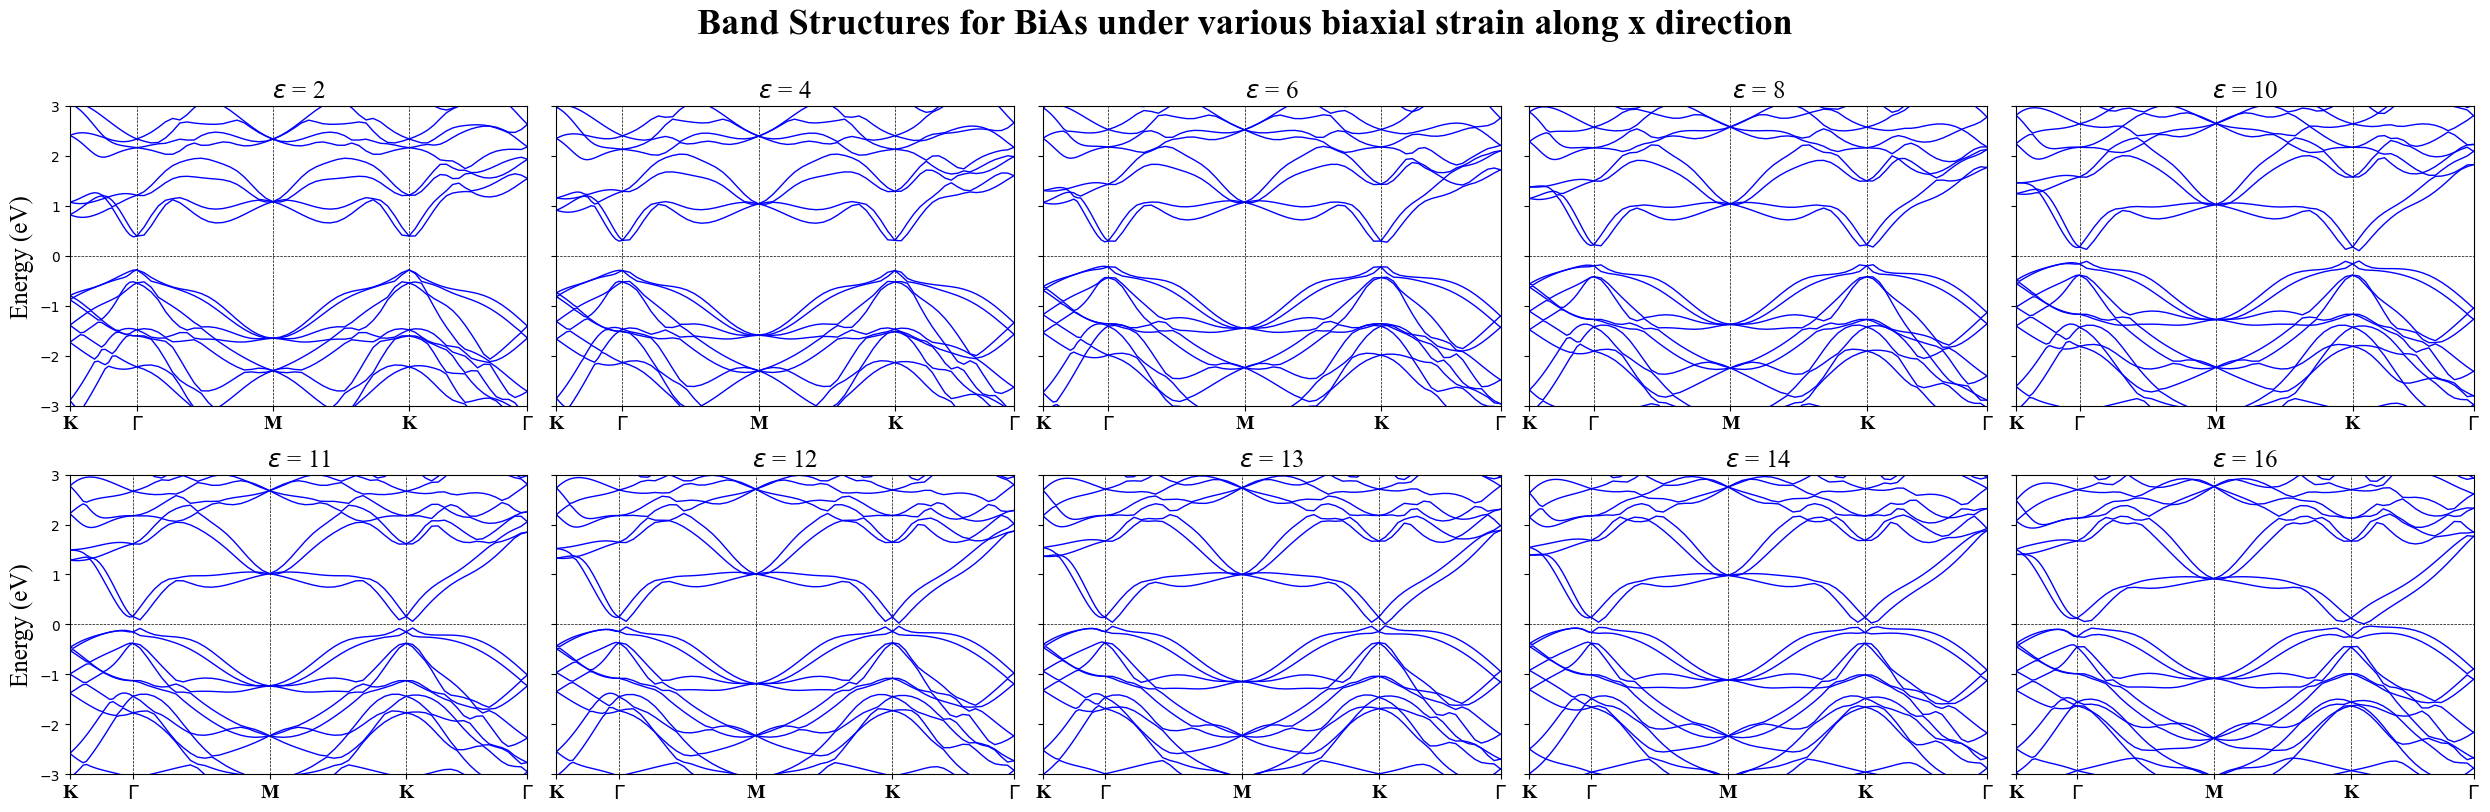

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for BiAs under various biaxial strain along x direction', fontsize=26, fontname="Times New Roman",fontweight="bold", y=1.01)
plt.savefig("bias-uniaxial-x-bands.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

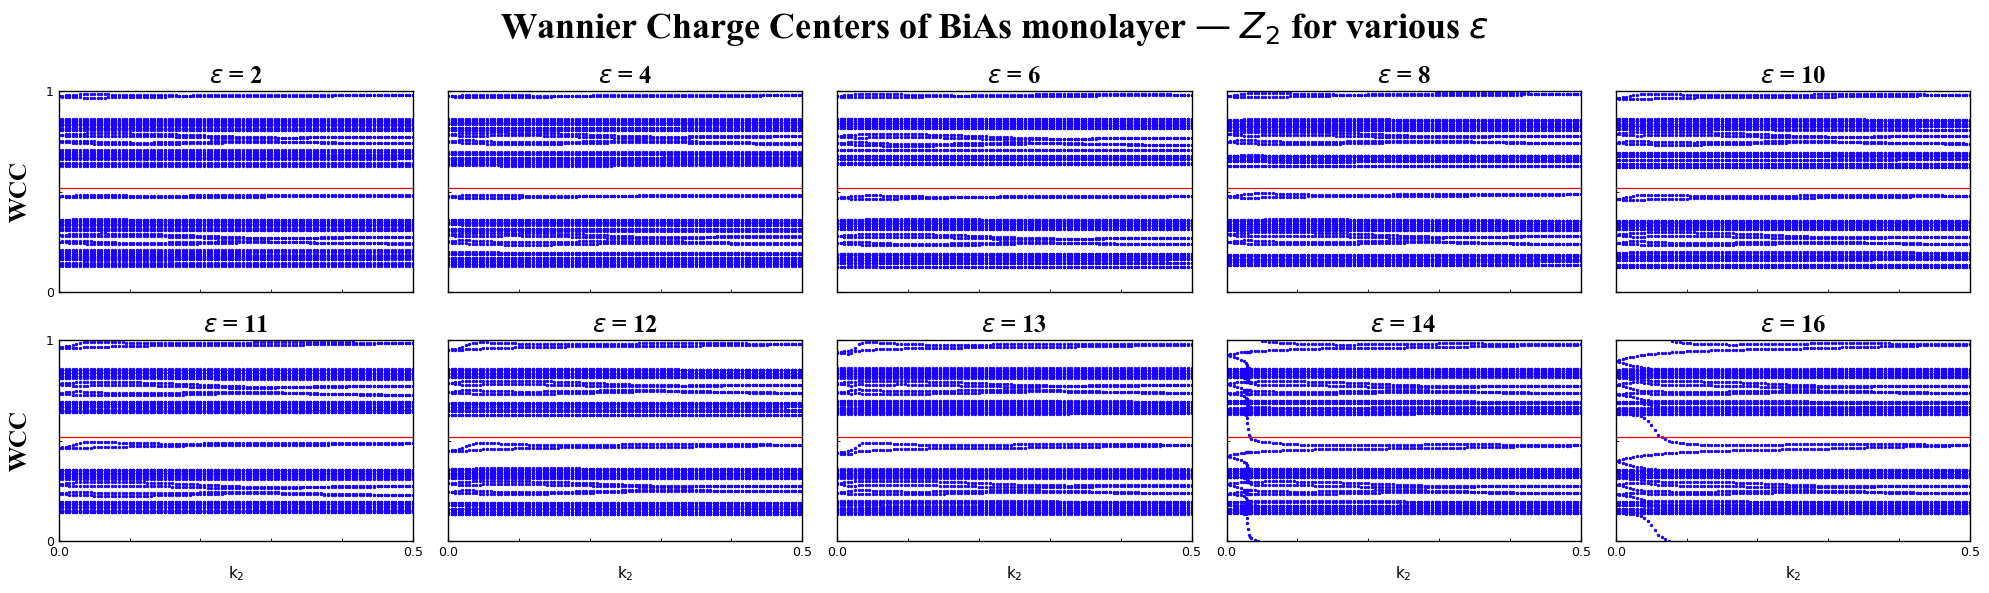

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = "#1900FF"
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2, color=LCOLOR, marker='o', linewidths=1)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)
    ax.axhline(0.52,lw = 0.9, color='red', ls = '-')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiAs monolayer — $Z_2$ for various $\epsilon$', fontname="Times New Roman",fontweight="bold",fontsize=26)
plt.tight_layout()
plt.savefig("bias_wannier_centers_comparison_uniaxial_x.png", dpi=300)
plt.show()

Global DOS range: [2.4265809, 7.7501838]


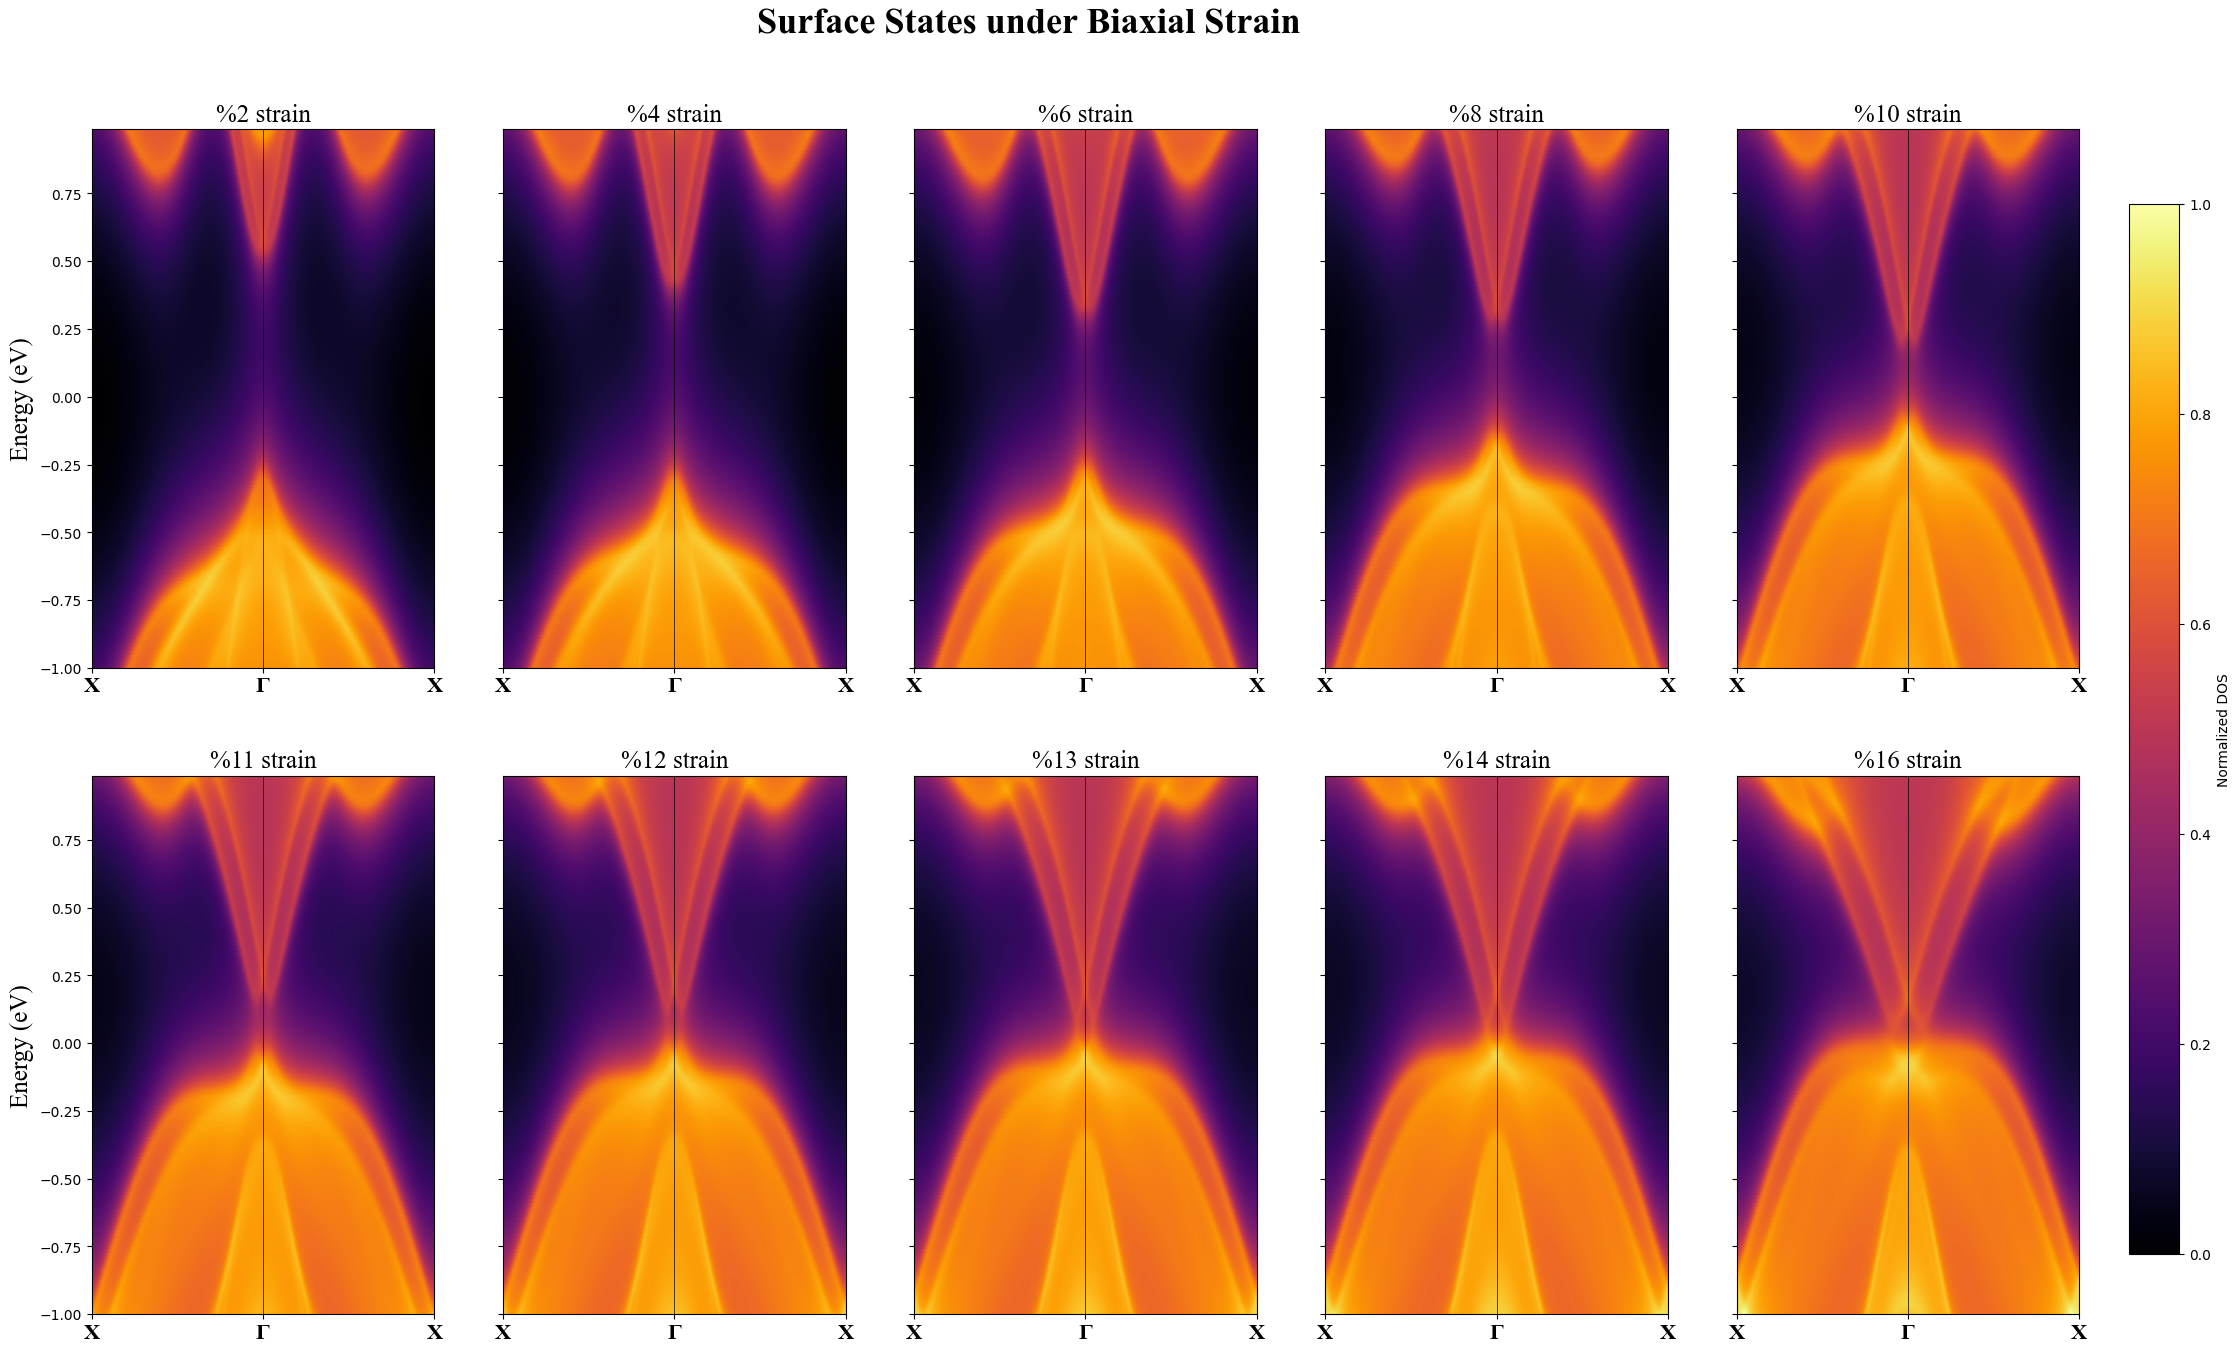

Plot displayed!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_11 = np.loadtxt("11-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_13 = np.loadtxt("13-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_11, data_12, data_13, data_14, data_16]
labels = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap="inferno", shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'],fontname="Times New Roman", fontweight="bold",fontsize=16)
    
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"%{title_suffix} strain",fontname="Times New Roman", fontsize=18)

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(2, 5, figsize=(25, 15),sharey=True)
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])
    if i == 0 or i == 5:
        axes[i].set_ylabel('Energy (eV)', fontname="Times New Roman", fontsize=18)
# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title

# Add overall title at the top
fig.suptitle("Surface States under Biaxial Strain", fontname="Times New Roman", fontweight="bold",fontsize=26, y=0.98)

# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.savefig("bias_surface_states_comparison_uniaxial_x.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot displayed!")

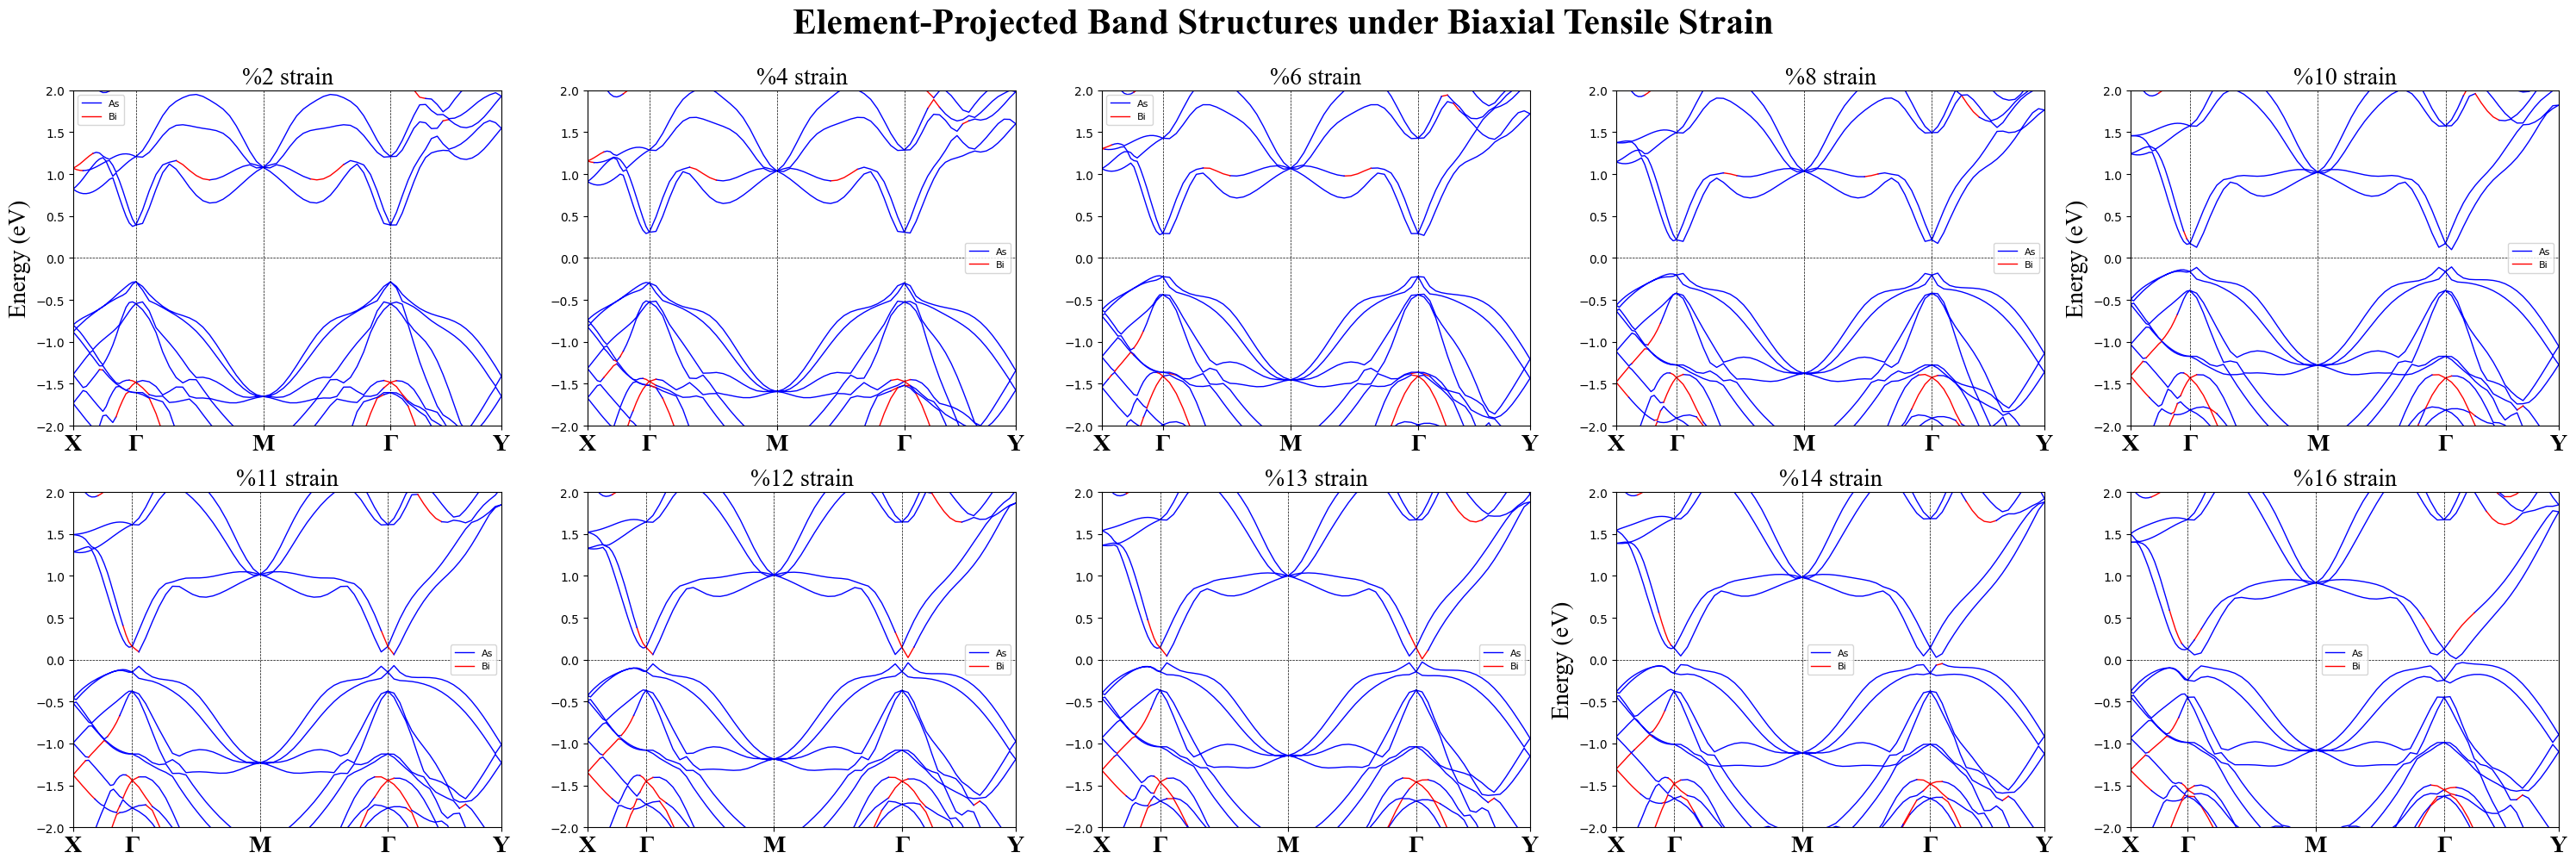

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_11 = np.loadtxt("11-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_13 = np.loadtxt("13-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")
data_16 = np.loadtxt("16-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14, data_16]

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

# Collect all datasets and their corresponding KLABELS files
labels = ['2', '4', '6', '8','10', '11' ,'12', '13' ,'14', '16']

datasets = []
klabels_list = []
for label in labels:
    datasets.append(np.loadtxt(f"{label}-PBAND_ELEMENTS_SOC.dat"))
    klabels_list.append(read_klabels(f"labels/{label}-KLABELS"))

# Define elements and their corresponding columns
element_names = ['Bi', 'As']
element_columns = [2, 3]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

high_sym_labels = ['X','Γ','M','Γ','Y']

# Create figure with subplots
fig, axes = plt.subplots(2,5, figsize=(30, 10))
axes = axes.flatten()

for idx, (elemented_data, label, sym_points) in enumerate(zip(datasets, labels, klabels_list)):
    ax = axes[idx]

    # Find dominant element at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)

    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))

    labeled_elements = set()

    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]

        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]

        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, label=elem_label, linewidth=1)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, linewidth=1)

    for point in sym_points:
        ax.axvline(point,lw=0.5,color='black',ls='--')

    ax.axhline(0,lw=0.5,color='black',ls='--')

    ax.set_xticks(sym_points)
    ax.set_xticklabels(high_sym_labels,fontname="Times New Roman",fontweight="bold",fontsize=20)
    ax.set_xlim(min(elemented_data[:, 0]), max(elemented_data[:, 0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain',fontsize=20,fontname="Times New Roman")
    if idx == 0 or idx == 4 or idx ==8:
        ax.set_ylabel('Energy (eV)',fontsize=20,fontname="Times New Roman")
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Biaxial Tensile Strain ",
            fontsize=30,fontname="Times New Roman", fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

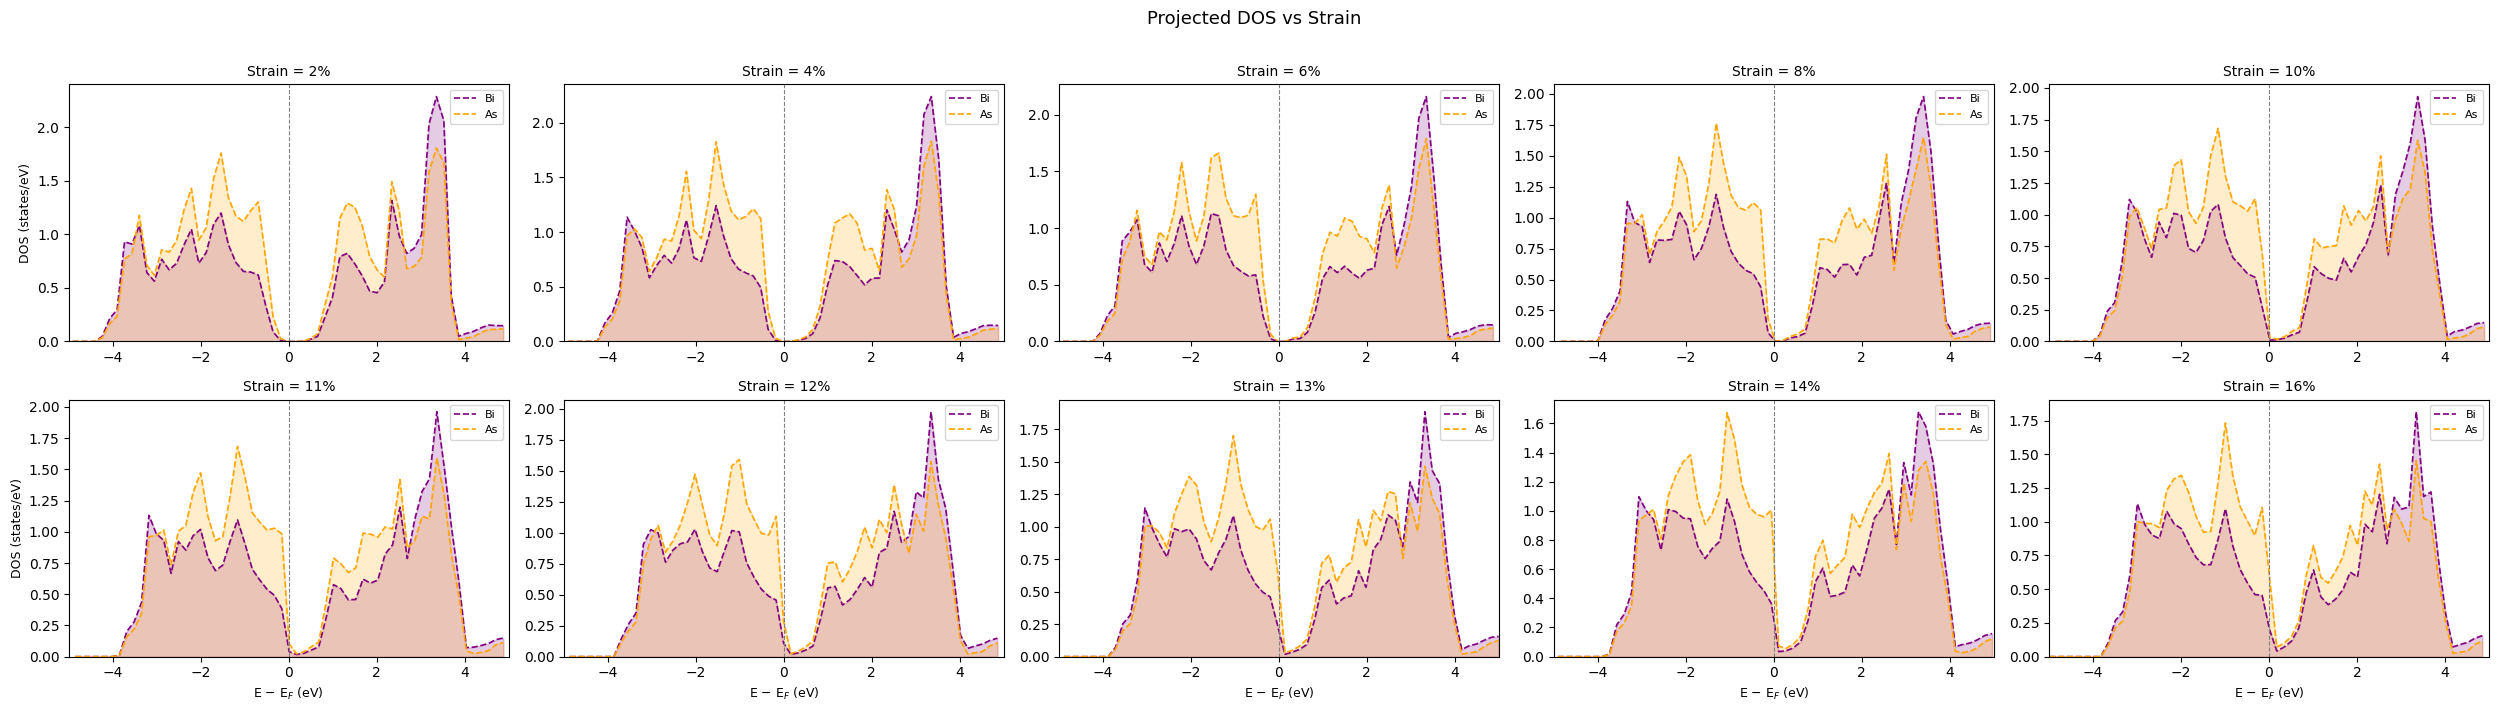

In [2]:
import numpy as np
import matplotlib.pyplot as plt

strains = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

e_min, e_max = -5.0, 5.0

n = len(strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, strain in enumerate(strains):
    ax = axes[i]

    # Load Bi and Sb PDOS
    bi_data = np.loadtxt(f'{strain}-PDOS_Bi_SOC.dat', unpack=True)
    sb_data = np.loadtxt(f'{strain}-PDOS_As_SOC.dat', unpack=True)

    energy = bi_data[0]
    tot_bi = bi_data[-1]   # last column = atom-summed total
    tot_sb = sb_data[-1]

    # Apply energy mask
    mask   = (energy >= e_min) & (energy <= e_max)
    energy = energy[mask]
    tot_bi = tot_bi[mask]
    tot_sb = tot_sb[mask]

    # Plot
    ax.plot(energy, tot_bi, label='Bi', color='purple', lw=1.2,ls = '--')
    ax.plot(energy, tot_sb, label='As', color='orange',  lw=1.2,ls = '--')
    ax.fill_between(energy, tot_bi, alpha=0.2, color='purple')
    ax.fill_between(energy, tot_sb, alpha=0.2, color='orange')

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(e_min, e_max)
    ax.set_ylim(bottom=0)
    ax.set_title(f'Strain = {strain}%', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

    # Only label outer axes
    if i % ncols == 0:
        ax.set_ylabel('DOS (states/eV)', fontsize=9)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel('E − E$_F$ (eV)', fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Projected DOS vs Strain', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('DOS_all_strains.png', dpi=150, bbox_inches='tight')
plt.show()